# **`mqqr` &mdash; full tutorial on real US macroeconomic data**

**Multivariate Quantile-on-Quantile Regression & Causality**

*Author: Dr. Merwan Roudane &middot; `merwanroudane920@gmail.com` &middot; [github.com/merwanroudane/qqrpy](https://github.com/merwanroudane/qqrpy)*

---

This notebook walks through the full `mqqr` library on real **quarterly US macroeconomic data** (1959 Q1 - 2009 Q3) from `statsmodels.datasets.macrodata`. We run five complete econometric workflows:

| # | Workflow                                                                 | Function                       |
|---|--------------------------------------------------------------------------|--------------------------------|
| 1 | Bivariate QQR &mdash; Phillips curve at quantiles                        | `qq_regression`                |
| 2 | Additive m-QQR (Type 1, Alola et al. 2023) &mdash; three drivers of INFL | `additive_mqq_regression`      |
| 3 | Moderated m-QQR (Type 2, Sinha et al. 2023) &mdash; main + moderators    | `mqq_regression`               |
| 4 | Bivariate QQ Granger causality                                           | `qq_causality`                 |
| 5 | Conditional (m-QQ) Granger causality                                     | `mqq_causality`                |

All figures use the **MATLAB Jet** colour-map at 300 dpi; all tables follow Elsevier / Springer journal format with `*`, `**`, `***` significance markers.

## 1. Setup &amp; data preparation

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.datasets.macrodata as macrodata

import mqqr
print(f'mqqr version: {mqqr.__version__}')

FIGDIR = 'docs/images'
TABDIR = 'docs/tables'
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABDIR, exist_ok=True)

# 9-point quantile grid (0.10, 0.20, ..., 0.90) -- journal-grade visuals
# but ~5x faster than the 19-point default for bootstrap-heavy estimators
QGRID = np.arange(0.10, 0.91, 0.10)
print(f'Quantile grid: {np.round(QGRID, 2)}')

mqqr version: 1.0.0
Quantile grid: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


In [2]:
raw = macrodata.load_pandas().data.copy()
raw['date'] = pd.PeriodIndex(
    year=raw['year'].astype(int),
    quarter=raw['quarter'].astype(int),
    freq='Q',
).to_timestamp()
raw = raw.set_index('date')

df = pd.DataFrame(index=raw.index)
df['INFL']   = raw['infl']                                  # CPI inflation (%)
df['GDP_GR'] = 100.0 * np.log(raw['realgdp']).diff()        # real GDP growth (%)
df['M1_GR']  = 100.0 * np.log(raw['m1']).diff()             # M1 growth (%)
df['UNEMP']  = raw['unemp']                                 # unemployment (%)
df['TBILL']  = raw['tbilrate']                              # 3-month T-bill (%)
df = df.dropna()

print(f'Sample: {df.index.min().date()} -- {df.index.max().date()}  (n = {len(df)})')
df.head()

Sample: 1959-04-01 -- 2009-07-01  (n = 202)


C:\Users\HP\AppData\Local\Temp\ipykernel_11064\4242810851.py:2: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  raw['date'] = pd.PeriodIndex(


,INFL,GDP_GR,M1_GR,UNEMP,TBILL
date,,,,,
1959-04-01,2.34,2.494213,1.421488,5.1,3.08
1959-07-01,2.74,-0.119295,-0.850466,5.3,3.82
1959-10-01,0.27,0.349453,-0.356507,5.6,4.33
1960-01-01,2.31,2.219018,-0.286123,5.2,3.50
1960-04-01,0.14,-0.468455,0.428878,5.2,2.68


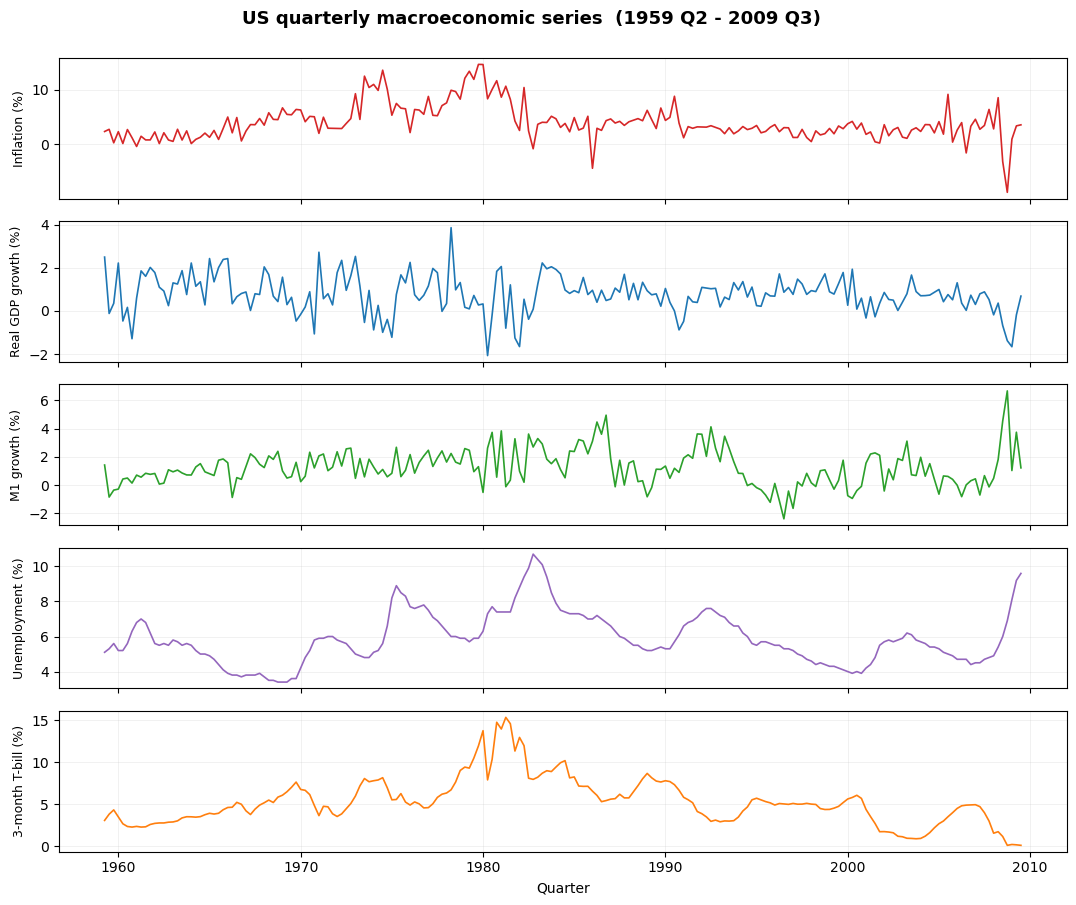

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(11, 9), sharex=True, facecolor='white')
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']
labels = ['Inflation (%)', 'Real GDP growth (%)', 'M1 growth (%)',
          'Unemployment (%)', '3-month T-bill (%)']
for ax, col, c, lab in zip(axes, df.columns, colors, labels):
    ax.plot(df.index, df[col], color=c, lw=1.2)
    ax.set_ylabel(lab, fontsize=9)
    ax.grid(True, alpha=0.3, linewidth=0.4)
axes[-1].set_xlabel('Quarter')
fig.suptitle('US quarterly macroeconomic series  (1959 Q2 - 2009 Q3)',
             fontsize=13, fontweight='bold', y=1.00)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/fig00_series_overview.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.  Descriptive statistics (Jarque-Bera + ARCH-LM)

In [4]:
desc = mqqr.descriptive_table({c: df[c].values for c in df.columns})
desc

,N,Mean,Median,Std,Min,Max,Skewness,Kurtosis,JB,JB_p,ARCH_LM,ARCH_LM_p
INFL,202,3.9809,3.2450,3.2492,-8.7900,14.6200,0.7387,5.2528,61.0888,0.0000,51.1185,0.0000
GDP_GR,202,0.7758,0.7652,0.8798,-2.0708,3.8585,-0.2106,4.0460,10.7016,0.0047,4.0962,0.0430
M1_GR,202,1.2294,1.0827,1.2936,-2.3927,6.6753,0.6041,4.2537,25.5143,0.0000,12.6331,0.0004
UNEMP,202,5.8851,5.6500,1.4622,3.4000,10.7000,0.7582,3.5889,22.2717,0.0000,173.1310,0.0000
TBILL,202,5.3241,5.0150,2.8045,0.1200,15.3300,0.9832,4.6458,55.3462,0.0000,134.8896,0.0000


In [5]:
with open(f'{TABDIR}/tab01_descriptive.md', 'w', encoding='utf-8') as f:
    f.write('# Descriptive statistics\n\n')
    f.write(desc.to_markdown(floatfmt='.4f'))
with open(f'{TABDIR}/tab01_descriptive.tex', 'w', encoding='utf-8') as f:
    f.write(desc.to_latex(float_format='%.4f',
                          caption='Descriptive statistics for US macro series',
                          label='tab:desc'))
desc.to_csv(f'{TABDIR}/tab01_descriptive.csv')
print('Saved tab01_descriptive.{md,tex,csv}')

Saved tab01_descriptive.{md,tex,csv}


## 3.  Workflow 1 &mdash; Bivariate QQR (Sim &amp; Zhou, 2015)

### Phillips curve at quantiles: does **unemployment** affect **inflation** differently across the inflation distribution?

$$
\mathrm{INFL}_t \;=\; \beta_0(\theta,\tau) \;+\; \beta_1(\theta,\tau)\bigl(\mathrm{UNEMP}_t-\mathrm{UNEMP}^{\tau}\bigr) \;+\; \alpha^\theta\,\mathrm{INFL}_{t-1} \;+\; v_t^\theta
$$

In [6]:
qq = mqqr.qq_regression(
    y=df['INFL'].values, x=df['UNEMP'].values,
    y_quantiles=QGRID, x_quantiles=QGRID,
    bandwidth=0.05, n_boot=60,
    x_name='UNEMP', y_name='INFL',
    verbose=False,
)
qq.summary()


+----------------------------------------------------+
|   Quantile-on-Quantile Regression  --  Summary     |
+----------------------------------------------------+

  Method            : Quantile-on-Quantile Regression (Sim & Zhou, 2015)
  Dependent (Y)     : INFL
  Independent (X)   : UNEMP
  Observations      : 201
  Bandwidth (h)     : 0.0500
  Y-quantiles (θ)   : 9  [0.10 … 0.90]
  X-quantiles (τ)   : 9  [0.10 … 0.90]
  Total cells       : 81
  Successful fits   : 81

  Slope β1(θ,τ)
    Mean   : -0.4084
    Median : -0.4540
    Min    : -12.4979
    Max    : +3.9771
    Std    : 2.0980

  Pseudo R^2
    Mean   : 0.2650
    Median : 0.2331

  Significance of β1(θ,τ)
    p < 0.10 :   10 / 81  (12.3%)
    p < 0.05 :    6 / 81  (7.4%)
    p < 0.01 :    4 / 81  (4.9%)



QQResult(results=    y_quantile  x_quantile     beta0     beta1        se   t_value   p_value  \
0          0.1         0.1  1.770068 -2.314992  1.216315 -1.903283  0.058454   
1          0.1         0.2  0.539885 -1.093957  1.323043 -0.826849  0.409318   
2          0.1         0.3  0.884256  1.769896  2.163303  0.818145  0.414258   
3          0.1         0.4 -1.908279 -1.448537  2.614758 -0.553985  0.580214   
4          0.1         0.5 -1.257825  2.624599  3.566856  0.735830  0.462705   
..         ...         ...       ...       ...       ...       ...       ...   
76         0.9         0.5  2.646132  1.025514  5.143538  0.199379  0.842171   
77         0.9         0.6  3.004534 -3.242389  1.131896 -2.864564  0.004626   
78         0.9         0.7  1.908764  0.773034  1.148936  0.672826  0.501842   
79         0.9         0.8  4.862113  3.977150  1.270782  3.129688  0.002014   
80         0.9         0.9  5.772715 -0.624138  1.322279 -0.472017  0.637435   

    r_squared  n_eff  

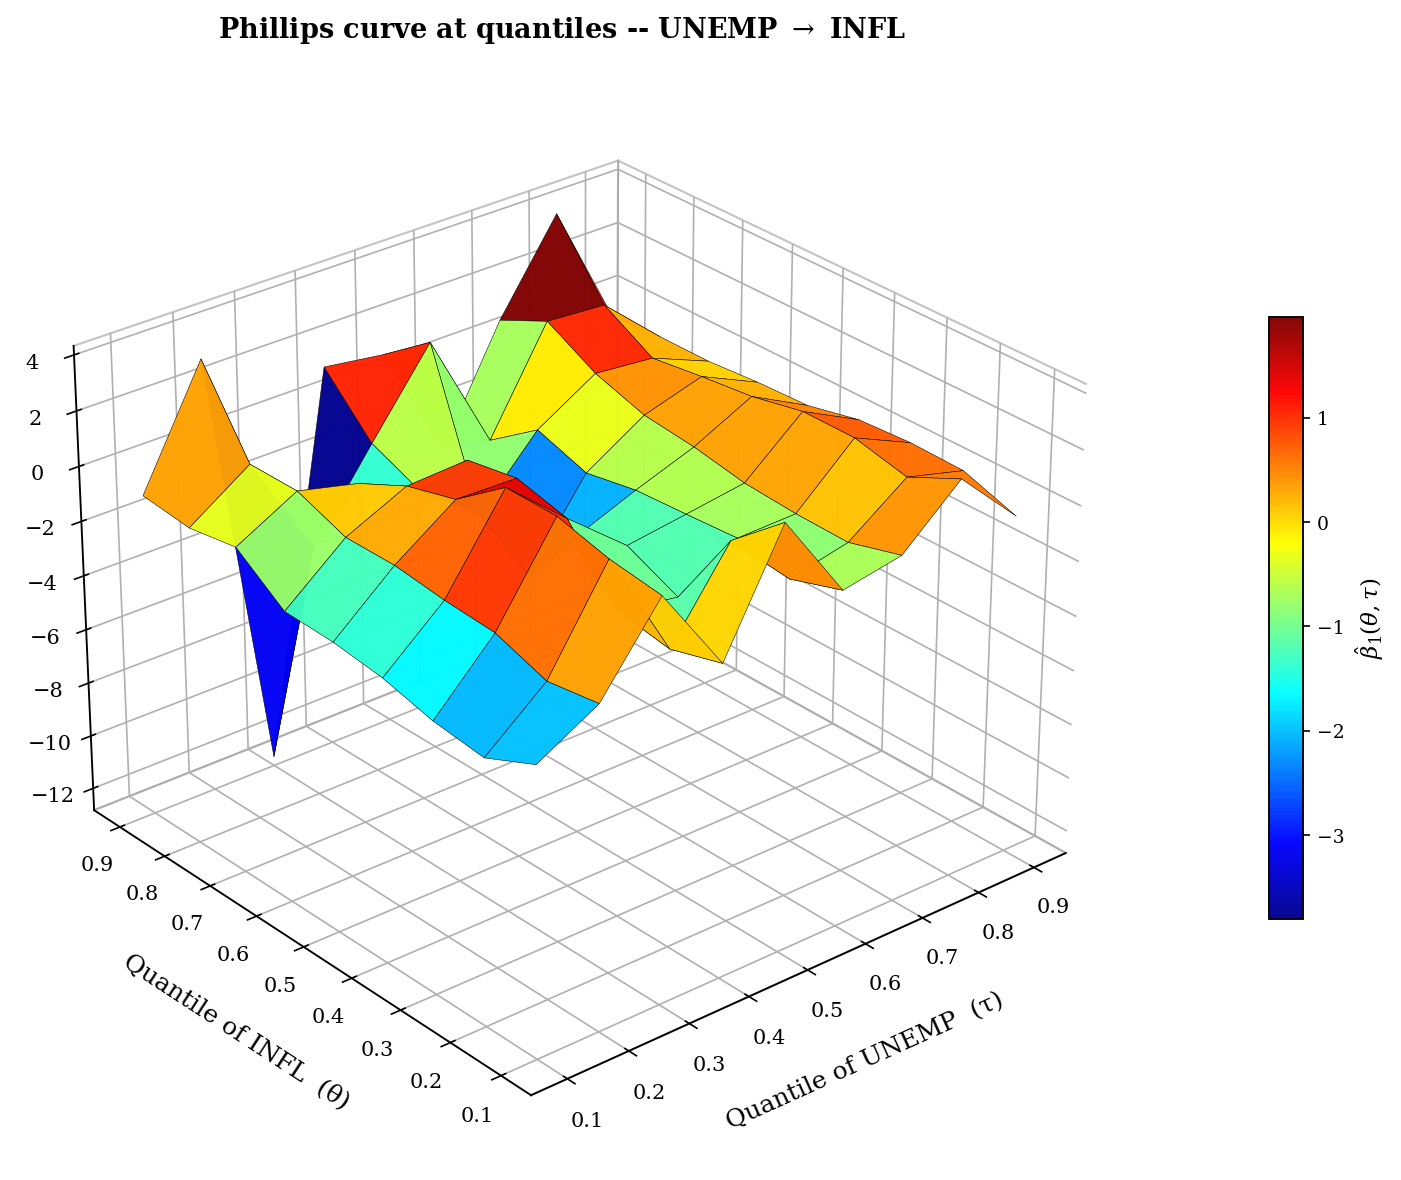

In [7]:
fig, ax = mqqr.plot_qq_3d(
    qq, cmap='jet', elev=28, azim=-130,
    title=r'Phillips curve at quantiles -- UNEMP $\to$ INFL',
    save_path=f'{FIGDIR}/fig01_qqr_3d.png',
)
plt.show()

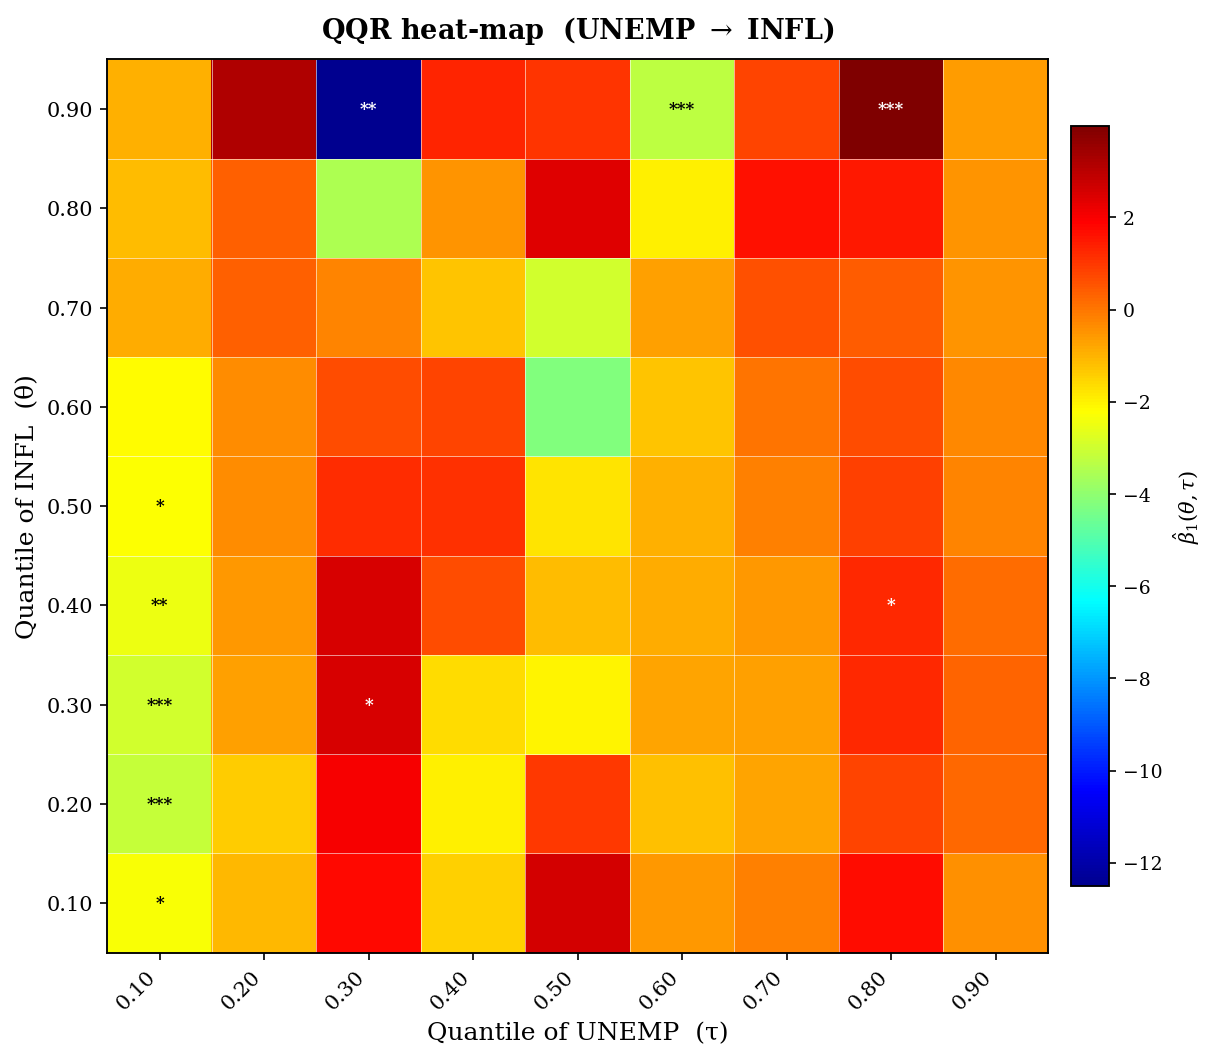

In [8]:
fig, ax = mqqr.plot_qq_heatmap(
    qq, cmap='jet', annotate='stars',
    title='QQR heat-map  (UNEMP $\\to$ INFL)',
    save_path=f'{FIGDIR}/fig02_qqr_heatmap.png',
)
plt.show()

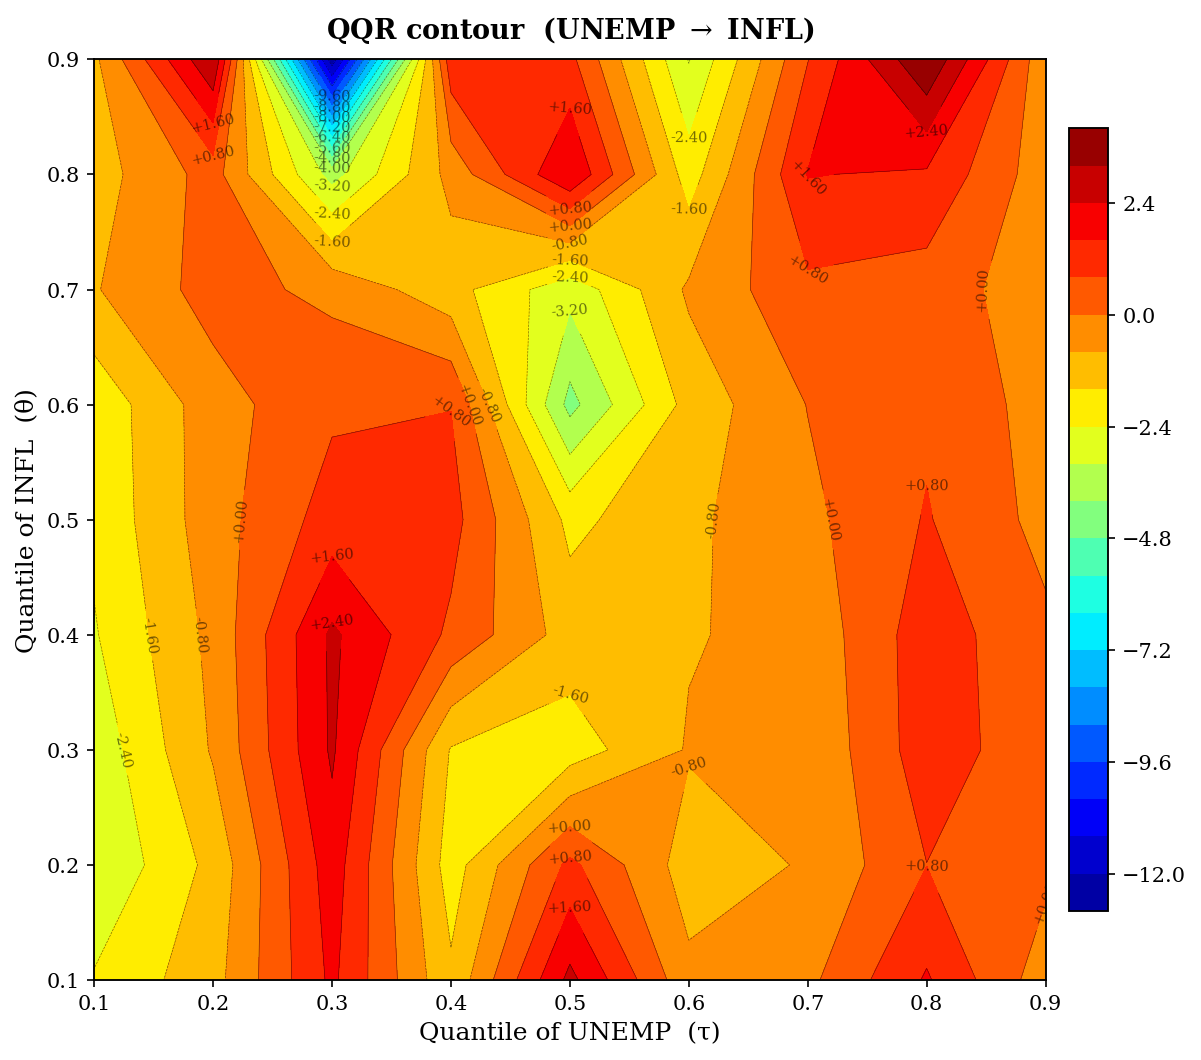

In [9]:
fig, ax = mqqr.plot_qq_contour(
    qq, cmap='jet',
    title='QQR contour  (UNEMP $\\to$ INFL)',
    save_path=f'{FIGDIR}/fig03_qqr_contour.png',
)
plt.show()

In [10]:
tbl_qq = mqqr.results_table(qq, value='beta1', digits=4)
tbl_qq.to_csv(f'{TABDIR}/tab02_qqr_beta1.csv')
with open(f'{TABDIR}/tab02_qqr_beta1.md', 'w', encoding='utf-8') as f:
    f.write('# QQR results -- $\\hat{\\beta}_1(\\theta,\\tau)$\n\n')
    f.write(mqqr.to_markdown(tbl_qq, caption='UNEMP -> INFL'))
with open(f'{TABDIR}/tab02_qqr_beta1.tex', 'w', encoding='utf-8') as f:
    f.write(mqqr.to_latex(tbl_qq,
                          caption=r'QQR slope $\hat{\beta}_1$ -- UNEMP $\to$ INFL',
                          label='tab:qqr',
                          notes=r'Stars: $^*p<0.10,\ ^{**}p<0.05,\ ^{***}p<0.01$.'))
tbl_qq

,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90
Y_q \ X_q,,,,,,,,,
0.10,-2.3150*,-1.0940,+1.7699,-1.4485,+2.6246,-0.5902,-0.1944,+1.6919,-0.4540
0.20,-3.1589***,-1.3652,+2.0320,-1.9809,+1.0033,-1.1968,-0.7288,+0.7909,+0.2165
0.30,-2.9357***,-0.7105,+2.5207*,-1.6610,-2.0093,-0.7330,-0.6816,+1.2414,+0.2696
0.40,-2.4703**,-0.5830,+2.5481,+0.6382,-1.1597,-0.8570,-0.5439,+1.2495*,+0.1618
0.50,-2.2342*,-0.3554,+1.1550,+1.0954,-1.8113,-0.9587,-0.1920,+0.8593,-0.2547
0.60,-2.1617,-0.3544,+0.6602,+0.7818,-4.2586,-1.2973,+0.0230,+0.6606,-0.3263
0.70,-0.8647,+0.3263,-0.2132,-1.2918,-2.9614,-0.6688,+0.6247,+0.4190,-0.4660
0.80,-1.1616,+0.3266,-3.5225,-0.5255,+2.3848,-2.0030,+1.6330,+1.4779,-0.4652
0.90,-0.9716,+3.1764,-12.4979**,+1.3381,+1.0255,-3.2424***,+0.7730,+3.9771***,-0.6241


## 4.  Workflow 2 &mdash; Additive m-QQR  (Type 1, Alola et al. 2023)

### Three drivers of inflation, each with its **own** quantile axis $\Phi_i$, no interactions

$$
\mathrm{INFL}_t = \beta_0(\theta,\Phi_1,\Phi_2,\Phi_3) + \sum_{i\in\{\text{GDP\_GR},\,\text{M1\_GR},\,\text{UNEMP}\}}\beta_i(\theta,\Phi_i)(x_{i,t}-x_i^{\Phi_i}) + \alpha^\theta\,\mathrm{INFL}_{t-1} + \epsilon_t^\theta
$$

In [11]:
amq = mqqr.additive_mqq_regression(
    y=df['INFL'].values,
    X={
        'GDP_GR': df['GDP_GR'].values,
        'M1_GR':  df['M1_GR'].values,
        'UNEMP':  df['UNEMP'].values,
    },
    y_quantiles=QGRID, x_quantiles=QGRID,
    bandwidth=0.05, n_boot=40,
    y_name='INFL',
    verbose=False,
)
amq.summary()


+----------------------------------------------------+
|  Additive m-QQR  (Alola et al. 2023)  - Summary    |
+----------------------------------------------------+

  Dependent (Y)     : INFL
  Regressors        : GDP_GR, M1_GR, UNEMP
  Observations      : 201
  Bandwidth (h)     : 0.0500
  Y-quantiles (theta): 9
  X-quantiles (Phi) : 9
  Y-lag included    : True

  Per-regressor slope summary
            GDP_GR :  mean = -0.1426   median = +0.3029   sig(5%) = 2/81
             M1_GR :  mean = +0.4096   median = +0.2854   sig(5%) = 5/81
             UNEMP :  mean = -0.2249   median = -0.0766   sig(5%) = 4/81



AdditiveMQQResult(surfaces={'GDP_GR':     y_quantile  x_quantile      beta        se   t_value   p_value  r_squared  \
0          0.1         0.1  0.583502  1.305497  0.446957  0.655399   0.305752   
1          0.1         0.2  3.904838  3.395007  1.150171  0.251475   0.369742   
2          0.1         0.3 -4.699913  4.225650 -1.112234  0.267400   0.090137   
3          0.1         0.4  3.673832  3.985865  0.921715  0.357810   0.090613   
4          0.1         0.5 -7.304366  4.244305 -1.720980  0.086832   0.134512   
..         ...         ...       ...       ...       ...       ...        ...   
76         0.9         0.5 -7.670047  8.657810 -0.885911  0.376751   0.298524   
77         0.9         0.6 -0.299754  5.192907 -0.057724  0.954028   0.606236   
78         0.9         0.7 -0.167116  1.571043 -0.106373  0.915395   0.548609   
79         0.9         0.8 -0.898995  1.557600 -0.577166  0.564489   0.537664   
80         0.9         0.9  0.593750  0.993812  0.597447  0.550898   0.

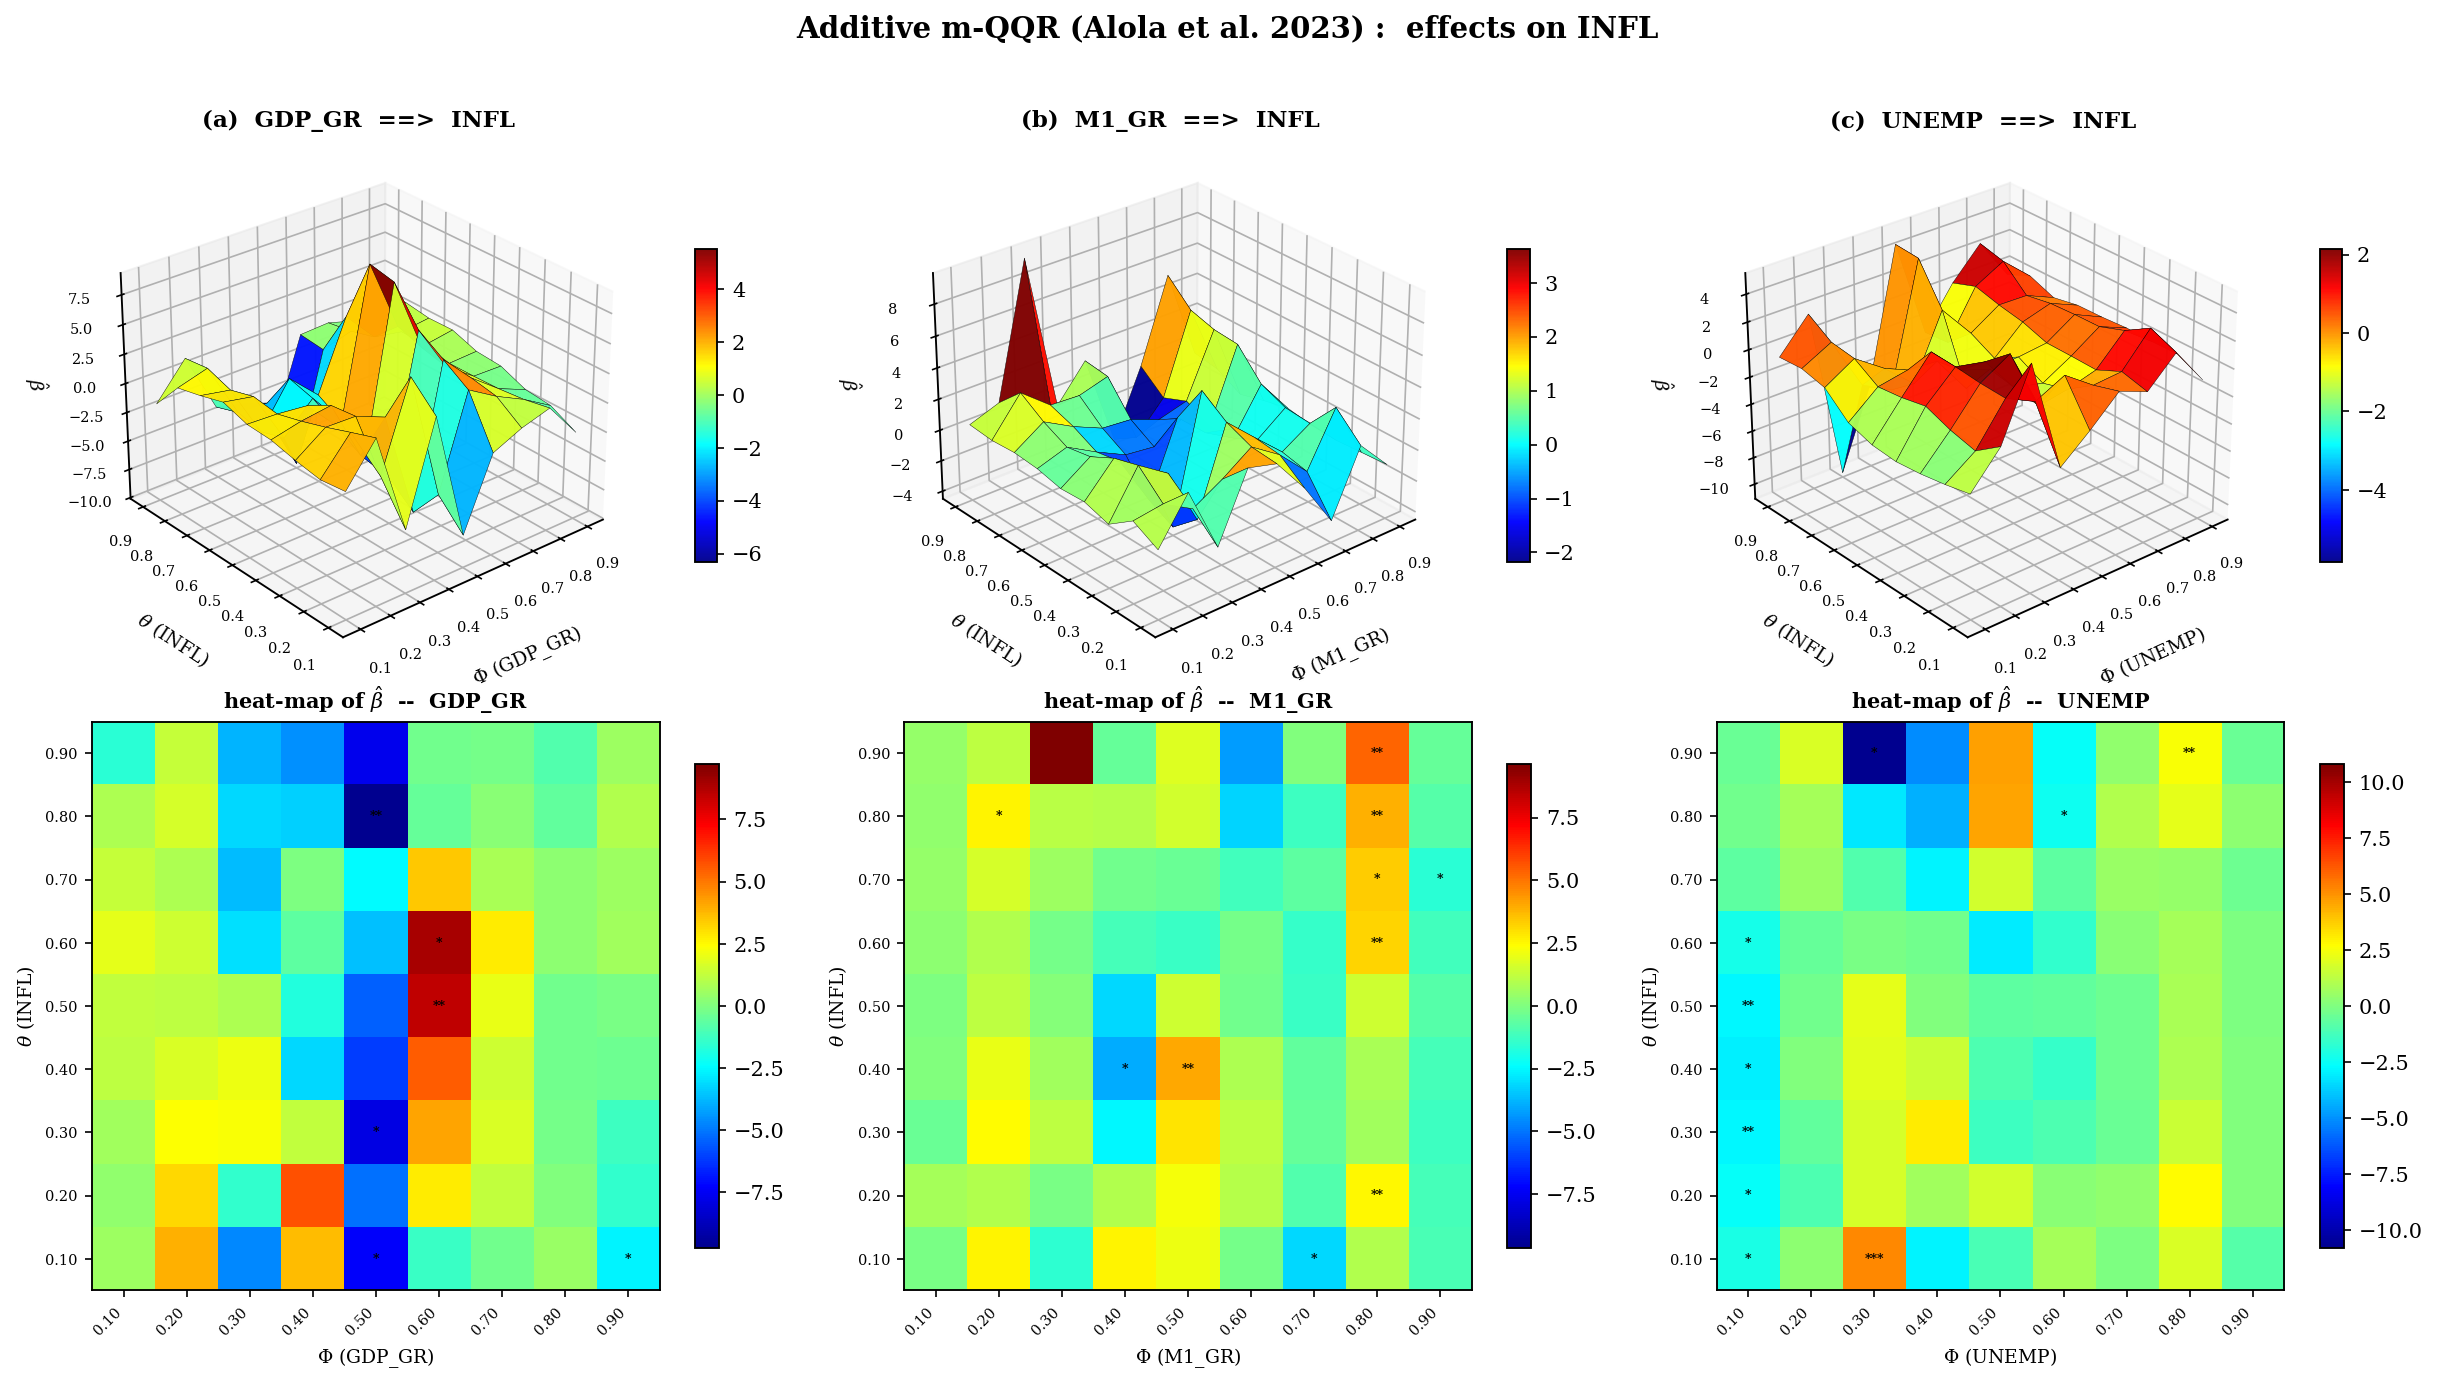

In [12]:
fig = mqqr.plot_additive_mqq_panel(
    amq, cmap='jet',
    save_path=f'{FIGDIR}/fig04_additive_mqqr_panel.png',
)
plt.show()

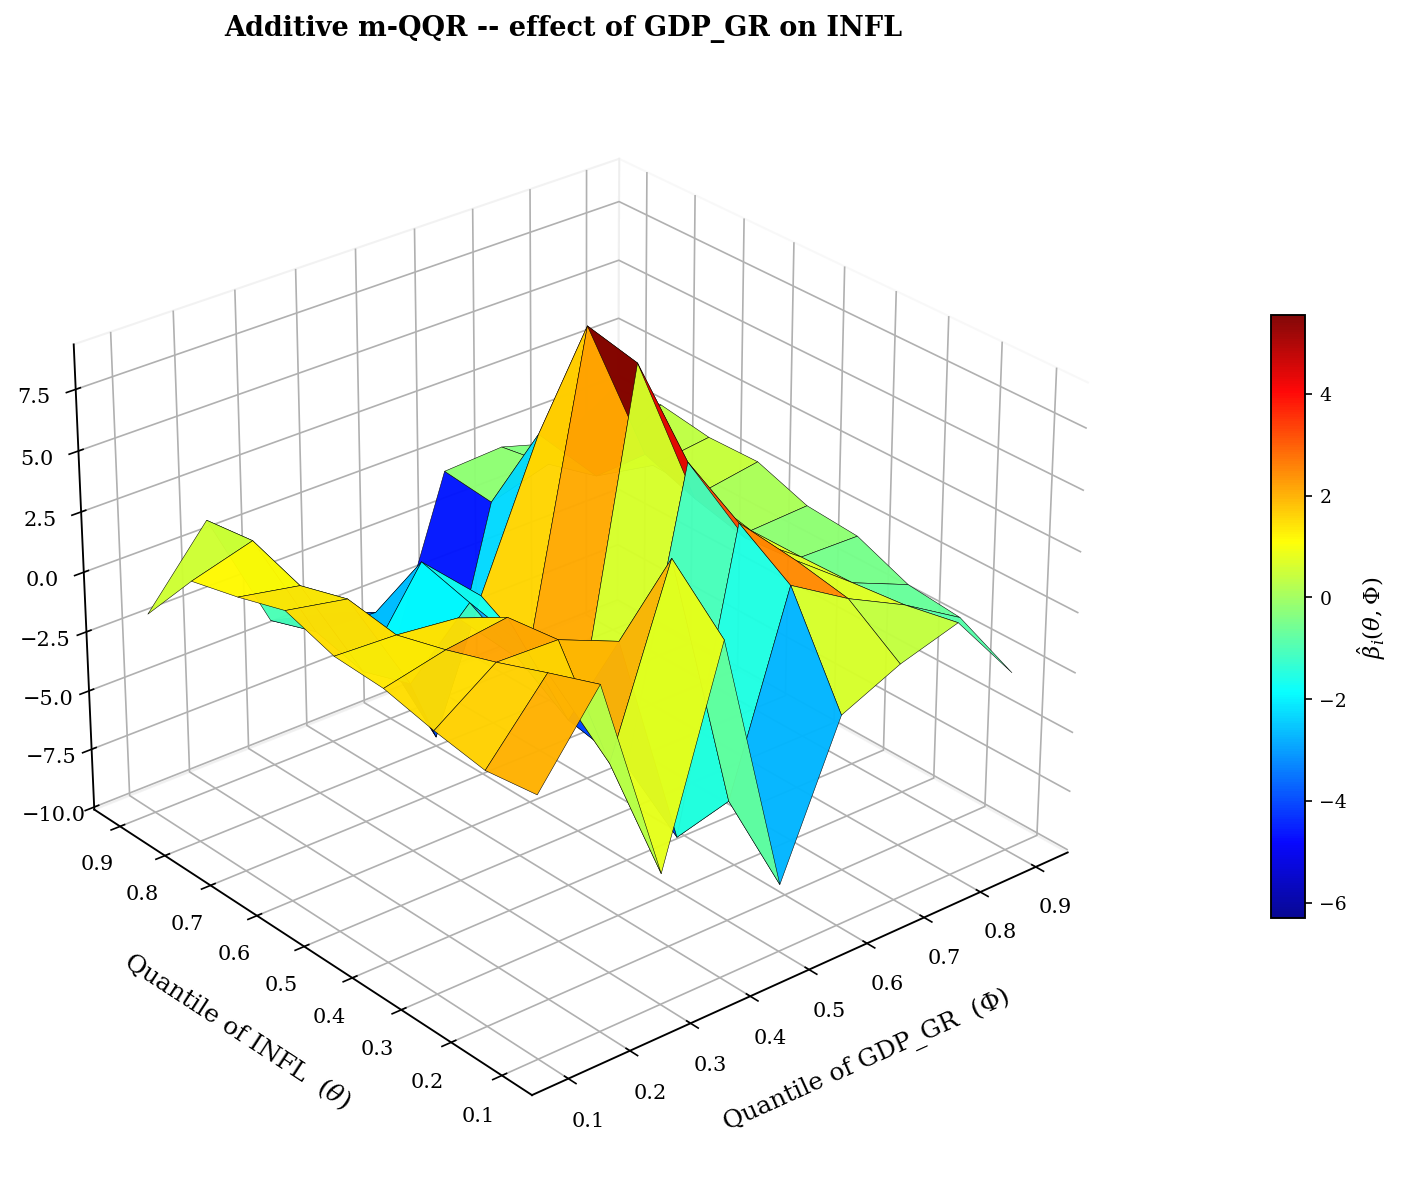

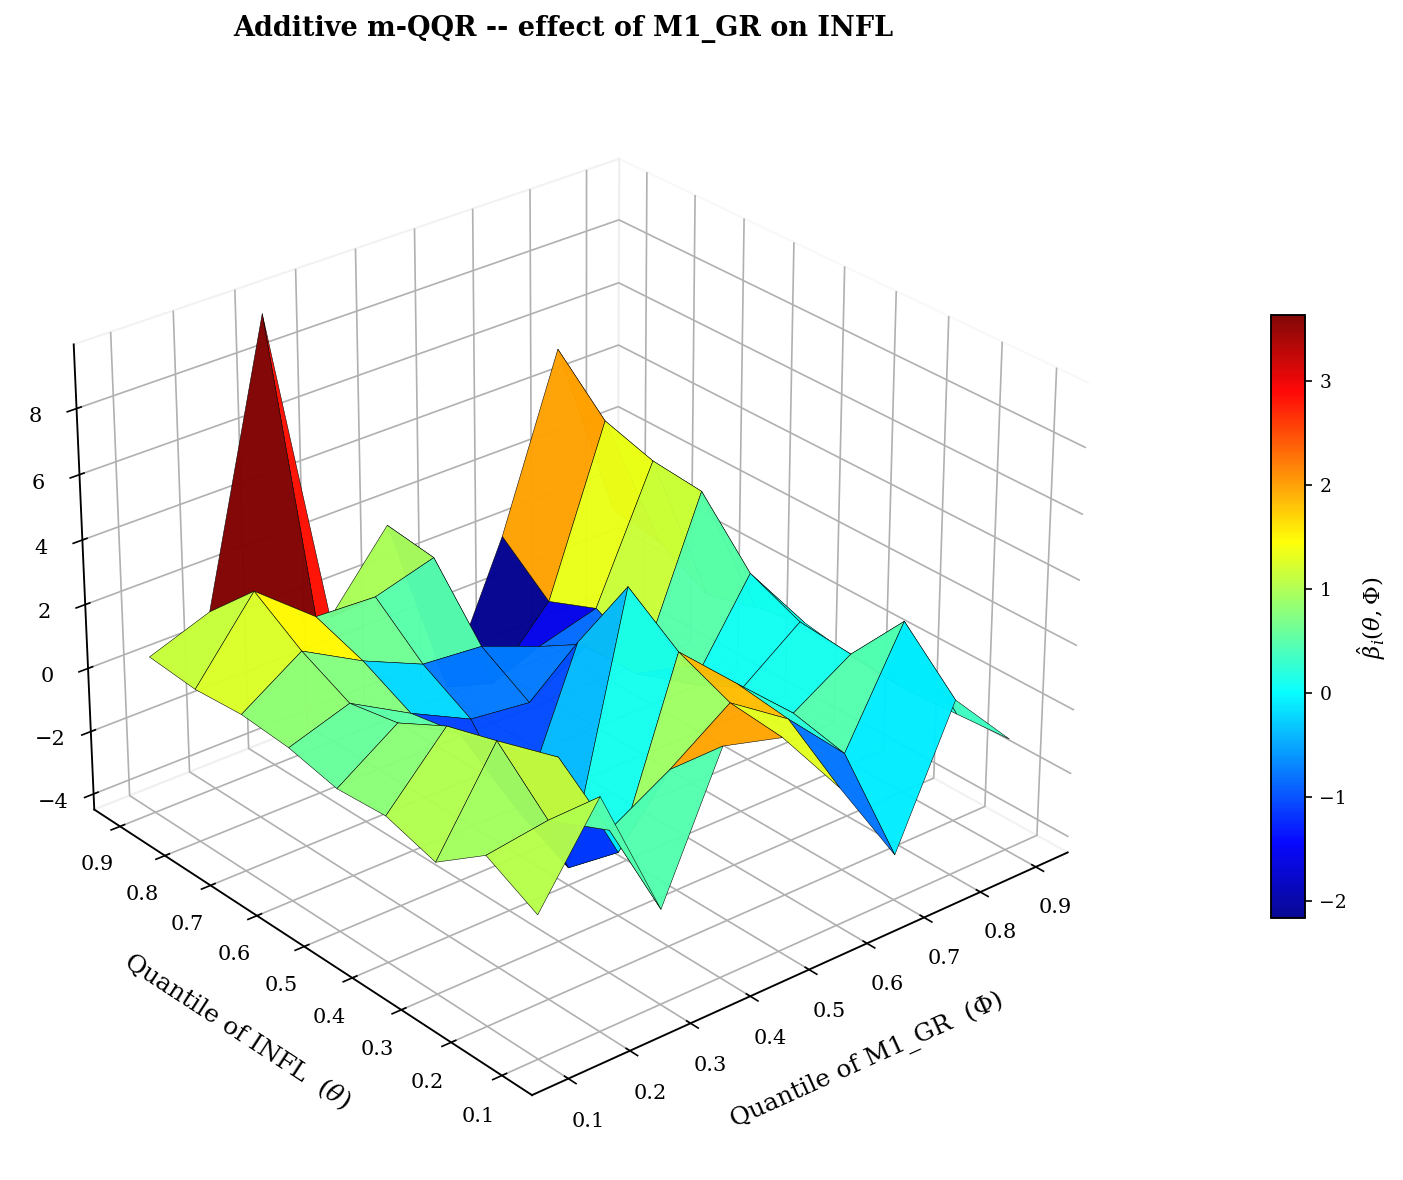

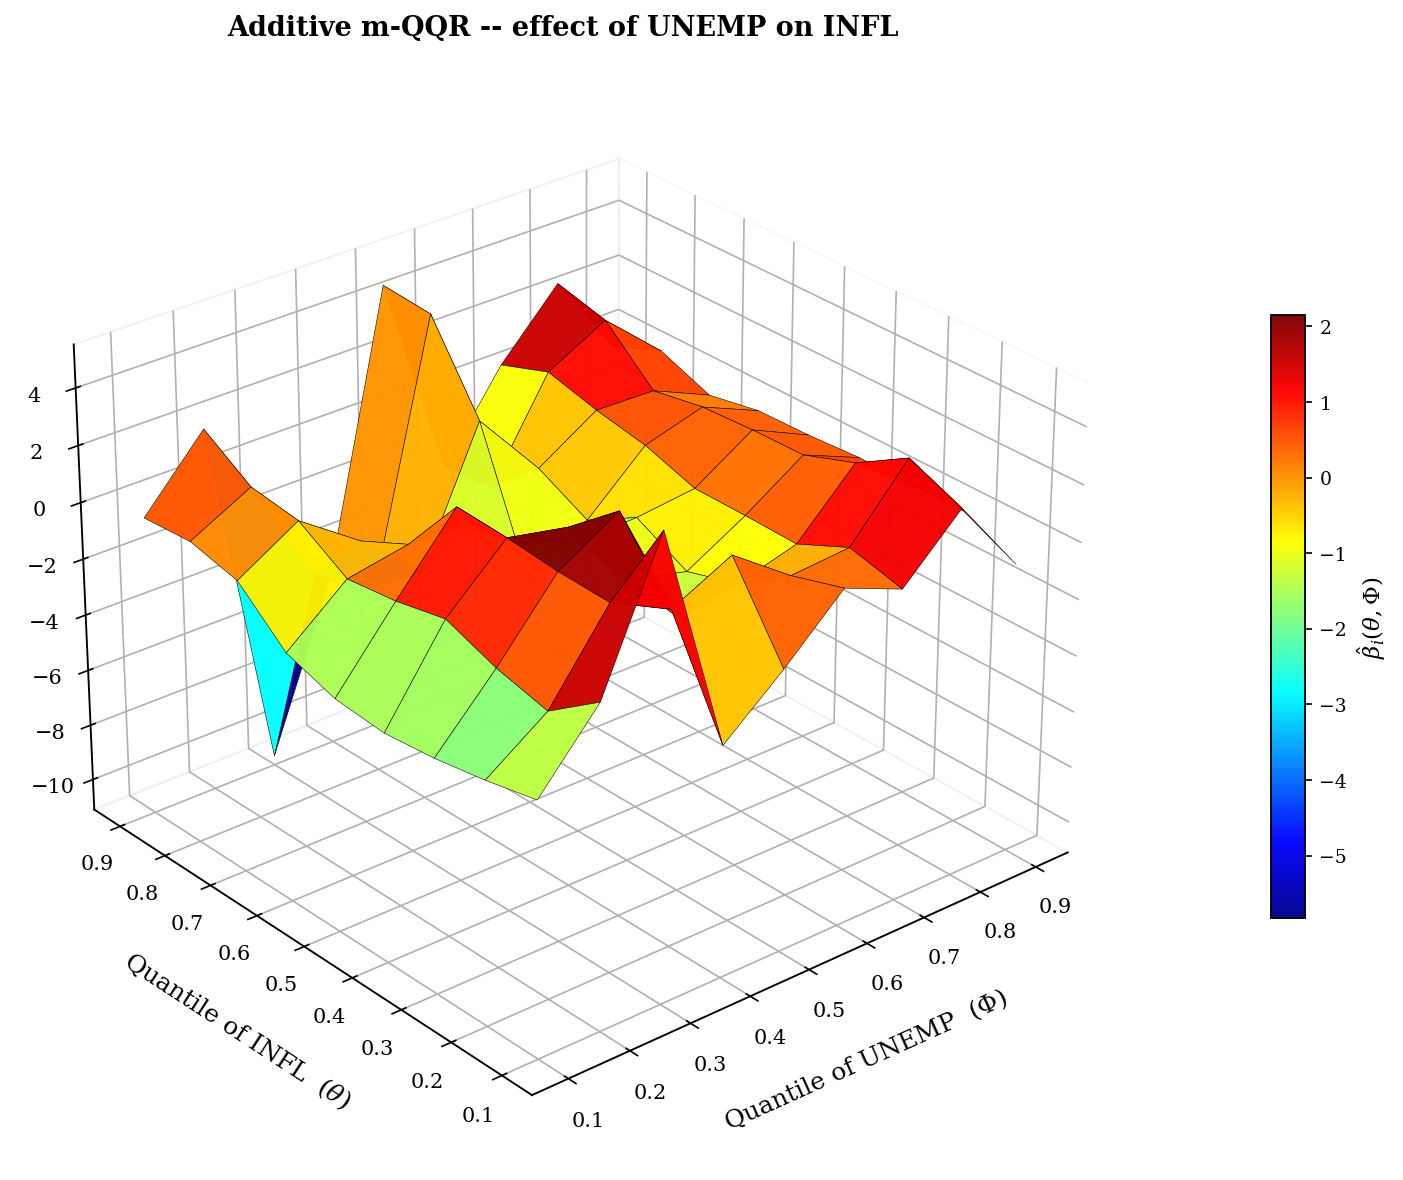

In [13]:
for name in amq.x_names:
    fig, ax = mqqr.plot_additive_mqq_3d(
        amq, name, cmap='jet',
        save_path=f'{FIGDIR}/fig05_amqqr_{name}_3d.png',
    )
    plt.show()
    plt.close(fig)

In [14]:
from mqqr import significance_stars

for name in amq.x_names:
    V = amq.to_matrix(name, 'beta')
    P = amq.to_matrix(name, 'p_value')
    yq = np.asarray(amq.y_quantiles, dtype=float)
    xq = np.asarray(amq.x_quantiles, dtype=float)
    cells = np.full(V.shape, '', dtype=object)
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            v = V[i, j]
            if np.isfinite(v):
                cells[i, j] = f'{v:+.4f}' + significance_stars(P[i, j])
            else:
                cells[i, j] = '--'
    out = pd.DataFrame(
        cells,
        index=[f'{q:.2f}' for q in yq],
        columns=[f'{q:.2f}' for q in xq],
    )
    out.index.name = 'Y_q \\ X_q'
    out.to_csv(f'{TABDIR}/tab03_amqqr_{name}.csv')
    with open(f'{TABDIR}/tab03_amqqr_{name}.md', 'w', encoding='utf-8') as f:
        f.write(f'# Additive m-QQR -- {name} $\\to$ INFL\n\n')
        f.write(mqqr.to_markdown(out))
    with open(f'{TABDIR}/tab03_amqqr_{name}.tex', 'w', encoding='utf-8') as f:
        f.write(mqqr.to_latex(out,
                              caption=f'Additive m-QQR: {name} $\\to$ INFL',
                              label=f'tab:amqqr_{name}',
                              notes=r'Stars: $^*p<0.10,\ ^{**}p<0.05,\ ^{***}p<0.01$.'))
    print(f'Saved tab03_amqqr_{name}')
out

Saved tab03_amqqr_GDP_GR
Saved tab03_amqqr_M1_GR
Saved tab03_amqqr_UNEMP


,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90
Y_q \ X_q,,,,,,,,,
0.10,-2.1402*,+0.2785,+5.1653***,-2.9292,-1.1671,+0.7801,-0.0749,+1.9077,-0.8535
0.20,-2.5300*,-1.0543,+1.7775,+0.7254,+1.7531,+0.2334,+0.3934,+2.7001,+0.0623
0.30,-2.8278**,-0.6063,+1.8491,+3.1034,-1.3974,-1.0250,-0.4461,+1.5995,+0.0280
0.40,-3.0052*,+0.0738,+2.0353,+1.5953,-1.0605,-1.5684,-0.4014,+0.9507,+0.0817
0.50,-2.8405**,-0.2993,+2.1383,+0.0264,-0.6951,-0.6211,-0.3845,+0.9156,-0.0367
0.60,-2.2551*,-0.5076,-0.1124,-0.2766,-3.0804,-1.6684,+0.2197,+0.8183,-0.0766
0.70,-0.7246,+0.5583,-0.9551,-2.8827,+1.7089,-0.7548,+0.5579,+0.4963,-0.4165
0.80,-0.3229,+0.7903,-3.1340,-4.3202,+4.5644,-2.3779*,+1.0219,+2.1461,+0.2940
0.90,-0.4511,+1.8938,-10.7834*,-5.0829,+4.7014,-2.5521,+0.3897,+2.5992**,-0.4533


## 5.  Workflow 3 &mdash; Moderated m-QQR  (Type 2, Sinha et al. 2023)

### **GDP growth** $\to$ **inflation**, moderated by **unemployment** and **M1 growth**, with $x\cdot Z$ interactions

$$
\mathrm{INFL}_t = \beta_0(\theta,\tau) + \beta_1(\theta,\tau)(\mathrm{GDP\_GR}_t-\mathrm{GDP\_GR}^\tau) + \sum_{j\in\{\text{UNEMP},\text{M1\_GR}\}}\!\!\bigl[\gamma_j(\theta,\tau)\,\mathrm{GDP\_GR}_t\cdot Z_{j,t} + \alpha_j(\theta)\,Z_{j,t}\bigr] + \epsilon_t^\theta
$$

In [15]:
mq = mqqr.mqq_regression(
    y=df['INFL'].values,
    x=df['GDP_GR'].values,
    moderators={
        'UNEMP': df['UNEMP'].values,
        'M1_GR': df['M1_GR'].values,
    },
    y_quantiles=QGRID, x_quantiles=QGRID,
    bandwidth=0.05, n_boot=40,
    x_name='GDP_GR', y_name='INFL',
    verbose=False,
)
mq.summary()


+----------------------------------------------------+
|  Multivariate Quantile-on-Quantile Reg. - Summary  |
+----------------------------------------------------+

  Method            : Multivariate Quantile-on-Quantile Regression (m-QQR)
  Dependent (Y)     : INFL
  Principal (X)     : GDP_GR
  Moderators        : UNEMP, M1_GR
  Observations      : 201
  Bandwidth (h)     : 0.0500
  Y-quantiles (θ)   : 9
  X-quantiles (τ)   : 9
  Total cells       : 81
  Successful fits   : 81

  Principal slope β1(θ,τ)
    Mean   : -1.1583
    Median : -0.2147
    Min    : -22.9707
    Max    : +19.0323

  Significance
    p < 0.10 :    0 / 81  (0.0%)
    p < 0.05 :    0 / 81  (0.0%)
    p < 0.01 :    0 / 81  (0.0%)

  Moderator interactions γ_j(θ,τ)
             UNEMP :  mean γ = +0.3252   sig(5%) = 0/81
             M1_GR :  mean γ = -0.5698   sig(5%) = 2/81



MQQResult(main_results=    y_quantile  x_quantile     beta0      beta1         se   t_value  \
0          0.1         0.1 -1.788246   0.432932   9.780655  0.044264   
1          0.1         0.2 -3.112391  -5.786187   6.782070 -0.853159   
2          0.1         0.3 -1.237616 -13.606604  29.838396 -0.456010   
3          0.1         0.4  1.128169 -13.810953  34.741566 -0.397534   
4          0.1         0.5  0.991300 -10.887826  32.793204 -0.332015   
..         ...         ...       ...        ...        ...       ...   
76         0.9         0.5  3.924737 -13.412142  28.224965 -0.475187   
77         0.9         0.6  2.921584  -4.842861  17.890296 -0.270698   
78         0.9         0.7  2.865979   6.603129  12.513639  0.527675   
79         0.9         0.8  3.758268  -1.176036   8.080299 -0.145544   
80         0.9         0.9  0.464603  -0.071727   4.521429 -0.015864   

     p_value  r_squared  n_eff  
0   0.964739   0.429873     84  
1   0.394623   0.402706    105  
2   0.648893 

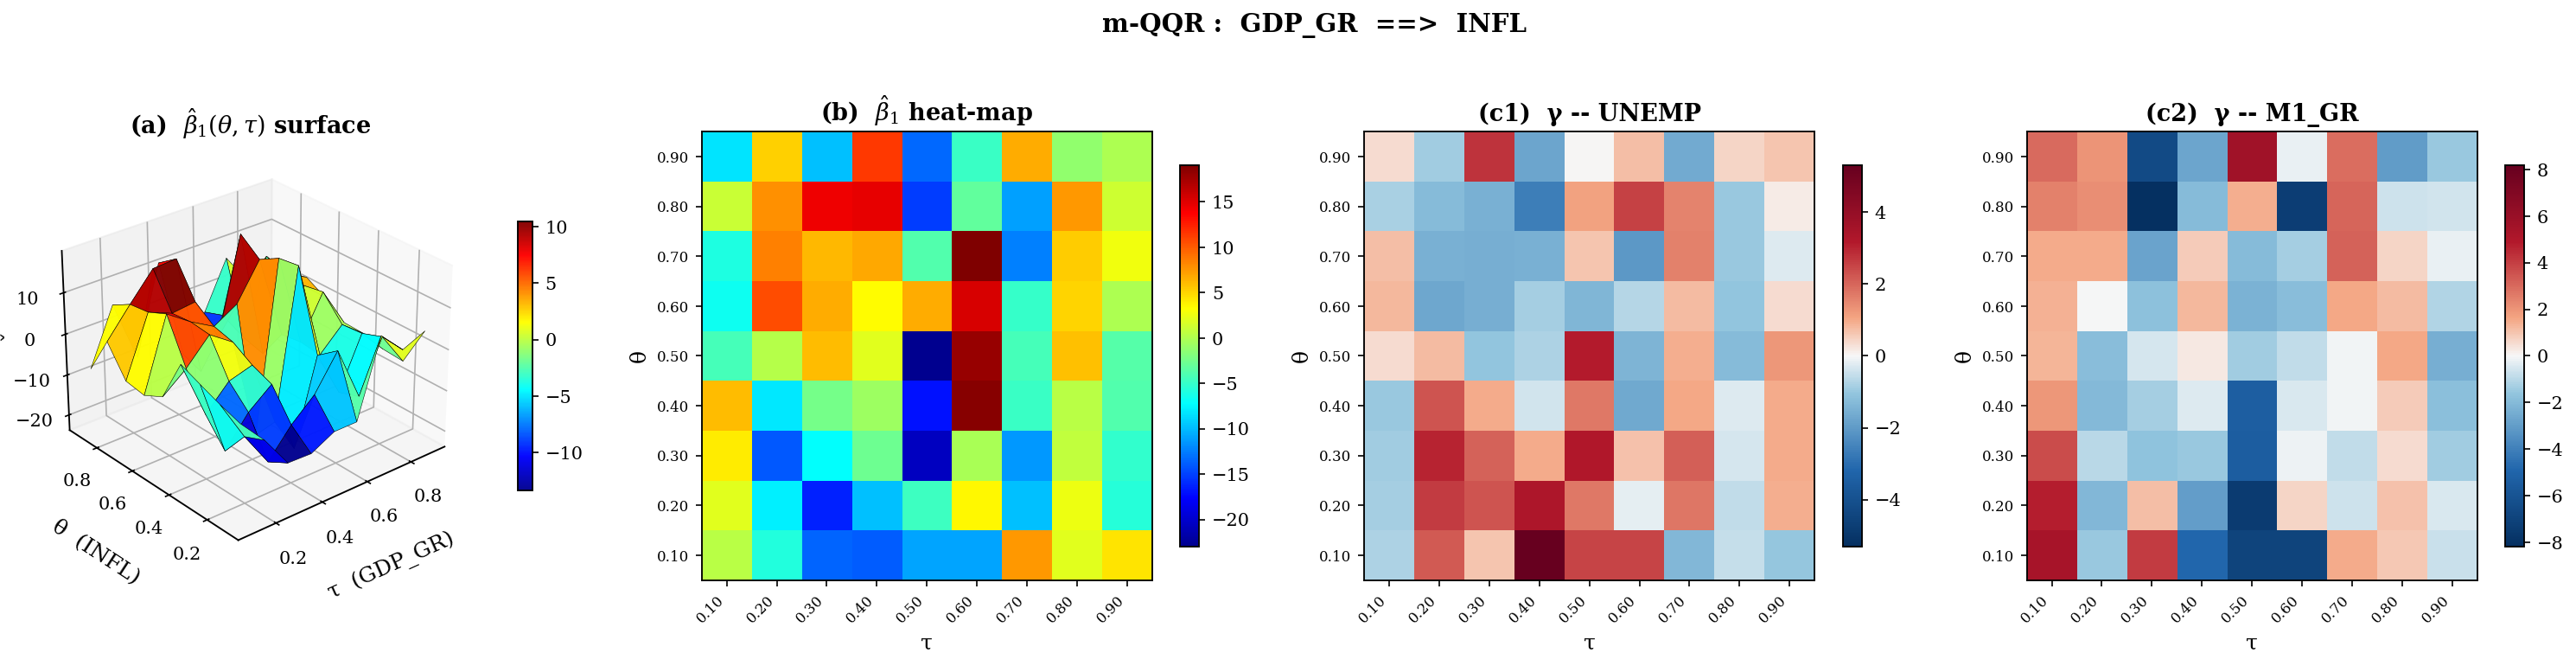

In [16]:
fig = mqqr.plot_mqq_panel(
    mq, cmap='jet',
    save_path=f'{FIGDIR}/fig06_mqqr_panel.png',
)
plt.show()

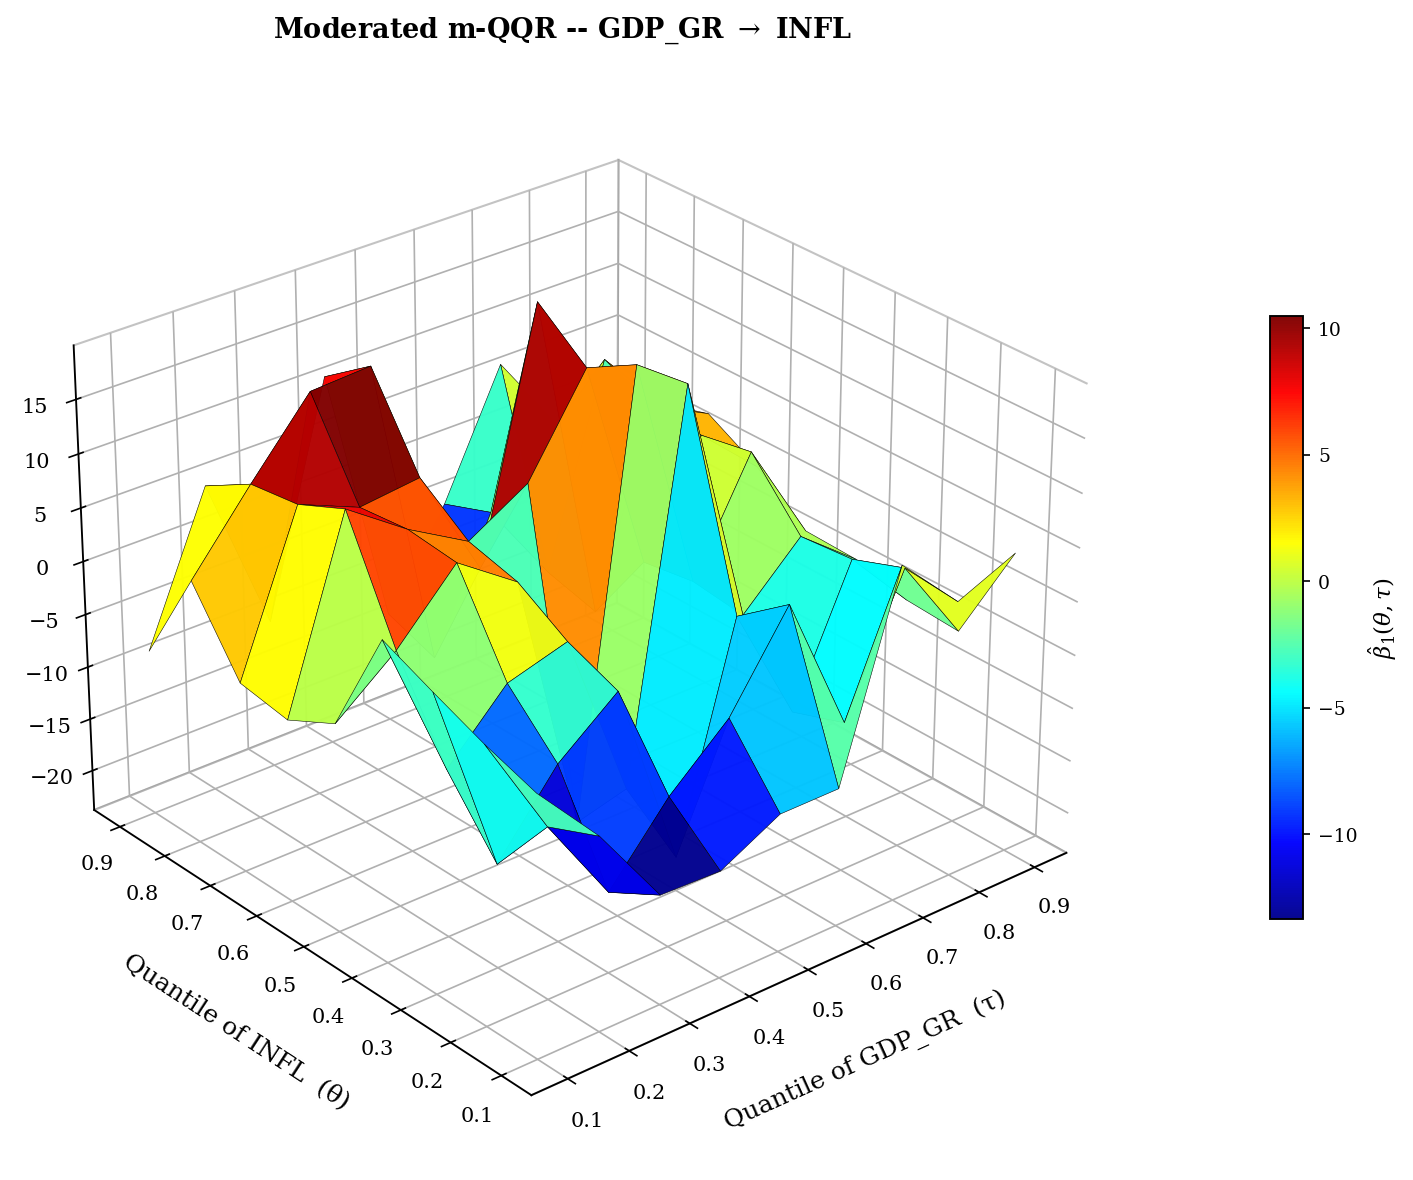

In [17]:
fig, ax = mqqr.plot_mqq_3d(
    mq, cmap='jet',
    title=r'Moderated m-QQR -- GDP$\_$GR $\to$ INFL',
    save_path=f'{FIGDIR}/fig07_mqqr_principal_3d.png',
)
plt.show()

In [18]:
tbl_mq = mqqr.results_table(mq, value='beta1', digits=4)
tbl_mq.to_csv(f'{TABDIR}/tab04_mqqr_beta1.csv')
with open(f'{TABDIR}/tab04_mqqr_beta1.md', 'w', encoding='utf-8') as f:
    f.write('# Moderated m-QQR -- principal slope $\\hat{\\beta}_1$\n\n')
    f.write(mqqr.to_markdown(tbl_mq, caption='GDP_GR -> INFL'))
with open(f'{TABDIR}/tab04_mqqr_beta1.tex', 'w', encoding='utf-8') as f:
    f.write(mqqr.to_latex(tbl_mq,
                          caption=r'Moderated m-QQR principal slope $\hat{\beta}_1$ -- GDP$\_$GR $\to$ INFL',
                          label='tab:mqqr_beta1',
                          notes=r'Stars: $^*p<0.10,\ ^{**}p<0.05,\ ^{***}p<0.01$.'))
tbl_mq

,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90
Y_q \ X_q,,,,,,,,,
0.10,+0.4329,-5.7862,-13.6066,-13.8110,-10.8878,-10.8772,+7.4717,+1.9801,+4.3094
0.20,+2.0383,-7.7786,-16.2550,-9.7195,-4.7566,+3.4731,-9.7430,+2.5118,-5.5797
0.30,+3.9837,-14.0918,-7.1477,-2.7070,-20.6586,-0.2147,-11.4394,+0.7771,-5.2272
0.40,+6.0262,-8.0988,-2.4034,-0.7831,-16.9254,+18.5611,-4.8970,+0.3798,-3.9037
0.50,-4.3087,+0.1786,+6.0486,+2.1226,-22.9707,+17.9186,-4.2856,+5.8565,-3.7163
0.60,-6.6801,+10.5314,+6.5750,+3.3455,+6.6467,+15.2871,-5.0013,+4.9983,-0.0246
0.70,-5.9249,+8.4584,+6.1024,+6.7675,-3.8539,+19.0323,-12.3636,+5.3471,+2.6372
0.80,+0.9957,+7.8432,+14.3439,+14.6921,-15.1059,-3.1539,-11.0997,+7.4432,+1.2390
0.90,-8.2383,+5.2103,-9.8079,+11.3486,-13.4121,-4.8429,+6.6031,-1.1760,-0.0717


In [19]:
for name in mq.moderator_names:
    G = mq.interaction_matrix(name, 'gamma')
    sub = mq.interactions[mq.interactions['moderator'] == name]
    P = sub.pivot(index='y_quantile', columns='x_quantile', values='p_value') \
           .sort_index(axis=0).sort_index(axis=1).values
    yq = np.asarray(mq.y_quantiles, dtype=float)
    xq = np.asarray(mq.x_quantiles, dtype=float)
    cells = np.full(G.shape, '', dtype=object)
    for i in range(G.shape[0]):
        for j in range(G.shape[1]):
            v = G[i, j]
            if np.isfinite(v):
                cells[i, j] = f'{v:+.4f}' + significance_stars(P[i, j])
            else:
                cells[i, j] = '--'
    out = pd.DataFrame(
        cells,
        index=[f'{q:.2f}' for q in yq],
        columns=[f'{q:.2f}' for q in xq],
    )
    out.index.name = 'Y_q \\ X_q'
    out.to_csv(f'{TABDIR}/tab05_mqqr_gamma_{name}.csv')
    with open(f'{TABDIR}/tab05_mqqr_gamma_{name}.md', 'w', encoding='utf-8') as f:
        f.write(f'# Moderation $\\gamma$ -- {name}\n\n')
        f.write(mqqr.to_markdown(out))
    with open(f'{TABDIR}/tab05_mqqr_gamma_{name}.tex', 'w', encoding='utf-8') as f:
        f.write(mqqr.to_latex(out,
                              caption=f'Moderation $\\gamma$ -- {name}',
                              label=f'tab:mqqr_gamma_{name}'))
    print(f'Saved tab05_mqqr_gamma_{name}')

Saved tab05_mqqr_gamma_UNEMP
Saved tab05_mqqr_gamma_M1_GR


## 6.  Workflow 4 &mdash; Bivariate QQ Granger causality

In [20]:
cq = mqqr.qq_causality(
    x=df['GDP_GR'].values, y=df['INFL'].values,
    y_quantiles=QGRID, x_quantiles=QGRID,
    bandwidth=0.05, n_boot=80,
    cause_name='GDP_GR', effect_name='INFL',
    verbose=False,
)
cq.summary()


+----------------------------------------------------+
|        QQ Granger Causality  --  Summary           |
+----------------------------------------------------+

  Direction         : GDP_GR  ==>  INFL
  Method            : QQ Granger Causality
  Observations      : 201
  Bandwidth (h)     : 0.0500
  Y-quantiles (θ)   : 9
  X-quantiles (τ)   : 9

  Causality across the (θ,τ) grid
    cells tested    : 81
    p < 0.10        :    4 (4.9%)
    p < 0.05        :    0 (0.0%)
    p < 0.01        :    0 (0.0%)

  Sup-Wald (Troster 2018) over (θ,τ)
    sup |t|         : 1.8857
    at  (θ*, τ*)    : (0.10, 0.30)
    Bonferroni p    : 1
    Reject H0 at 5% : False



QQCausalityResult(results=    y_quantile  x_quantile      beta1        se   t_value   p_value
0          0.1         0.1  -1.043796  1.937397 -0.538762  0.590656
1          0.1         0.2   3.504917  2.113688  1.658200  0.098861
2          0.1         0.3   8.762343  4.646623  1.885744  0.060794
3          0.1         0.4  -8.759943  5.130187 -1.707529  0.089291
4          0.1         0.5  11.191192  7.284238  1.536357  0.126047
..         ...         ...        ...       ...       ...       ...
76         0.9         0.5   3.625195  6.587179  0.550341  0.582706
77         0.9         0.6  11.688586  7.981271  1.464502  0.144643
78         0.9         0.7   0.766961  9.447586  0.081181  0.935380
79         0.9         0.8  -0.596073  2.159103 -0.276074  0.782779
80         0.9         0.9   1.036268  1.605684  0.645375  0.519431

[81 rows x 6 columns], y_quantiles=array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]), x_quantiles=array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]), n_

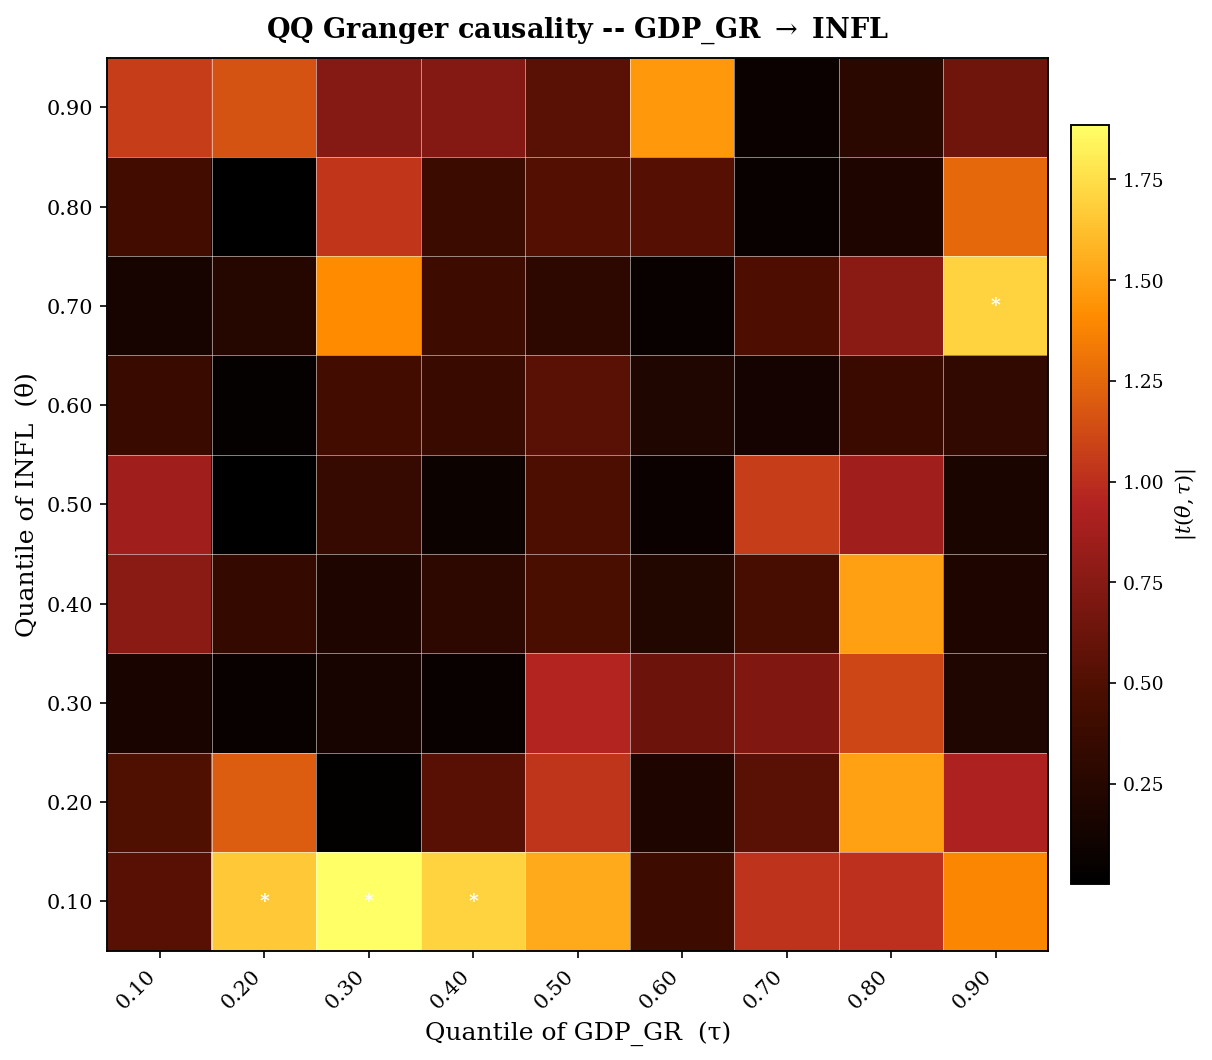

In [21]:
fig, ax = mqqr.plot_qq_causality_heatmap(
    cq, cmap='red_yellow_black', show_stars=True,
    title=r'QQ Granger causality -- GDP$\_$GR $\to$ INFL',
    save_path=f'{FIGDIR}/fig08_qq_causality.png',
)
plt.show()

## 7.  Workflow 5 &mdash; Conditional (m-QQ) Granger causality

In [22]:
mcq = mqqr.mqq_causality(
    x=df['GDP_GR'].values, y=df['INFL'].values,
    moderators={
        'UNEMP': df['UNEMP'].values,
        'M1_GR': df['M1_GR'].values,
    },
    y_quantiles=QGRID, x_quantiles=QGRID,
    bandwidth=0.05, n_boot=50,
    cause_name='GDP_GR', effect_name='INFL',
    verbose=False,
)
mcq.summary()


+----------------------------------------------------+
|        QQ Granger Causality  --  Summary           |
+----------------------------------------------------+

  Direction         : GDP_GR  ==>  INFL
  Method            : Multivariate QQ Granger Causality (conditional)
  Observations      : 201
  Bandwidth (h)     : 0.0500
  Y-quantiles (θ)   : 9
  X-quantiles (τ)   : 9

  Causality across the (θ,τ) grid
    cells tested    : 81
    p < 0.10        :    0 (0.0%)
    p < 0.05        :    0 (0.0%)
    p < 0.01        :    0 (0.0%)

  Sup-Wald (Troster 2018) over (θ,τ)
    sup |t|         : 1.6326
    at  (θ*, τ*)    : (0.80, 0.60)
    Bonferroni p    : 1
    Reject H0 at 5% : False



MQQCausalityResult(results=    y_quantile  x_quantile      beta1         se   t_value   p_value
0          0.1         0.1  13.440122   9.782060  1.373956  0.171041
1          0.1         0.2   1.092132  10.193445  0.107141  0.914788
2          0.1         0.3  18.099976  41.277786  0.438492  0.661518
3          0.1         0.4 -34.707064  34.496635 -1.006100  0.315621
4          0.1         0.5   4.865138  31.506142  0.154419  0.877440
..         ...         ...        ...        ...       ...       ...
76         0.9         0.5  37.913993  29.979580  1.264661  0.207510
77         0.9         0.6  23.513195  29.498860  0.797088  0.426374
78         0.9         0.7 -24.748233  19.252936 -1.285426  0.200176
79         0.9         0.8  -8.978196  10.542571 -0.851614  0.395479
80         0.9         0.9  -3.855013   8.254726 -0.467007  0.641019

[81 rows x 6 columns], y_quantiles=array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]), x_quantiles=array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0

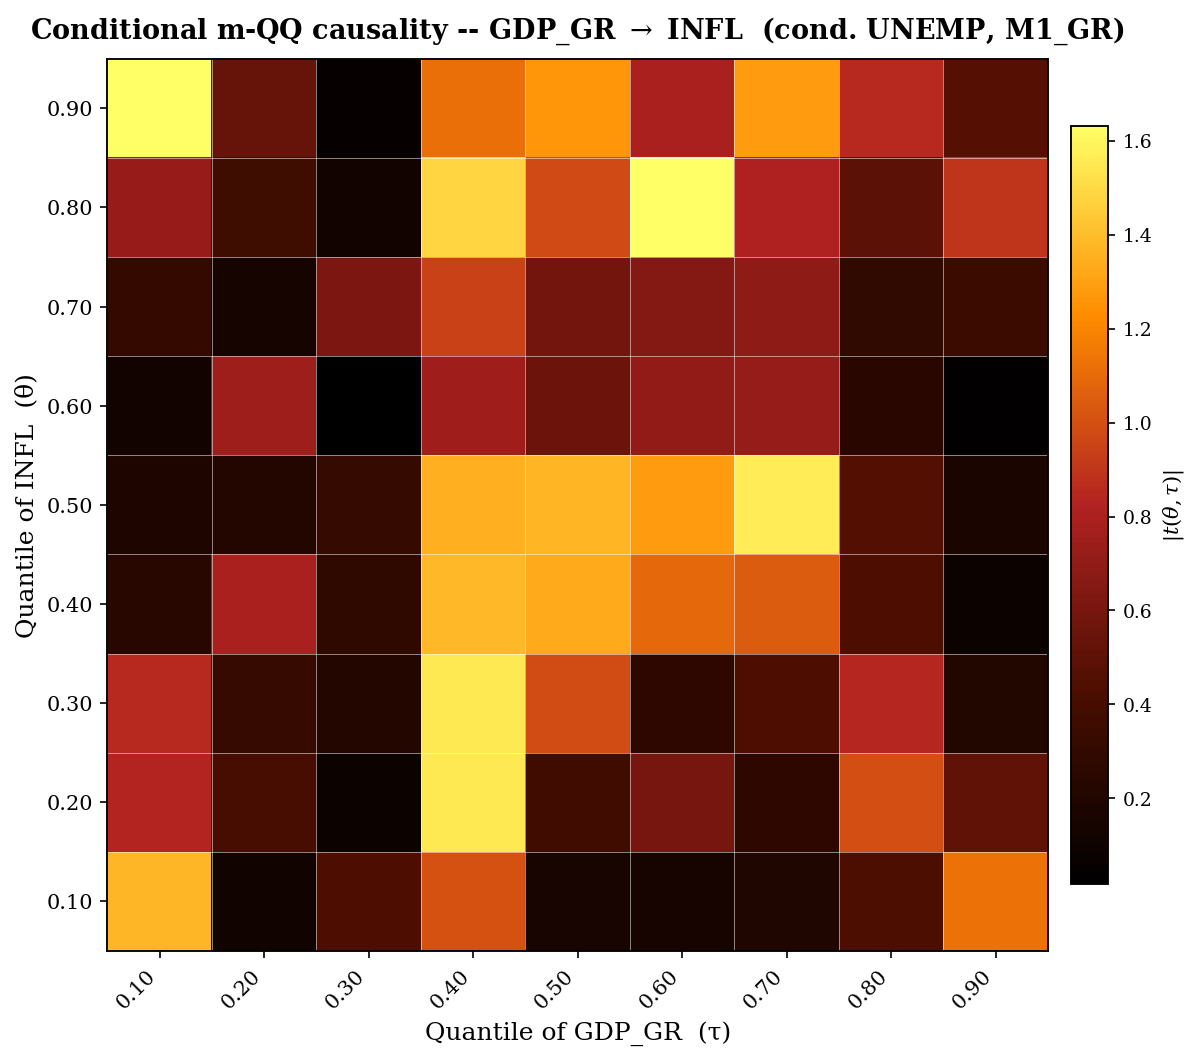

In [23]:
fig, ax = mqqr.plot_qq_causality_heatmap(
    mcq, cmap='red_yellow_black', show_stars=True,
    title=r'Conditional m-QQ causality -- GDP$\_$GR $\to$ INFL  (cond. UNEMP, M1$\_$GR)',
    save_path=f'{FIGDIR}/fig09_mqq_causality.png',
)
plt.show()

## 8.  Colour-map gallery

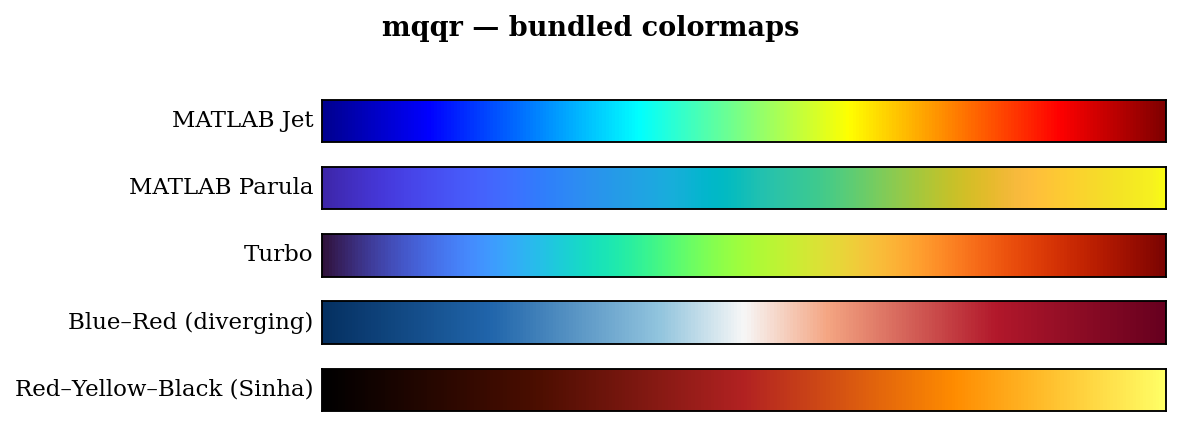

In [24]:
fig = mqqr.show_colormaps()
fig.savefig(f'{FIGDIR}/fig10_colormaps.png', dpi=300, bbox_inches='tight')
plt.show()

## 9.  Done

All figures and tables were saved into `docs/images/` and `docs/tables/`, ready for GitHub Pages.

---

**License:** MIT &copy; 2026 Dr. Merwan Roudane  
**GitHub:** <https://github.com/merwanroudane/qqrpy>  
**PyPI:** <https://pypi.org/project/mqqr/>